<a href="https://colab.research.google.com/github/xEzIxX/AI-Class/blob/master/week2/breast_cancer_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np;

# 파일 경로 설정
# 이미 전문가에 의해 특징이 추출된 데이터
file_path = '/content/drive/MyDrive/Colab Notebooks/breast_cancer.csv';

# 데이터 읽기
df = pd.read_csv(file_path);

# 상위 5개 행 확인
# print(df.head());
df.head()

,Unnamed: 0,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Text(0.5, 1.0, 'Label')

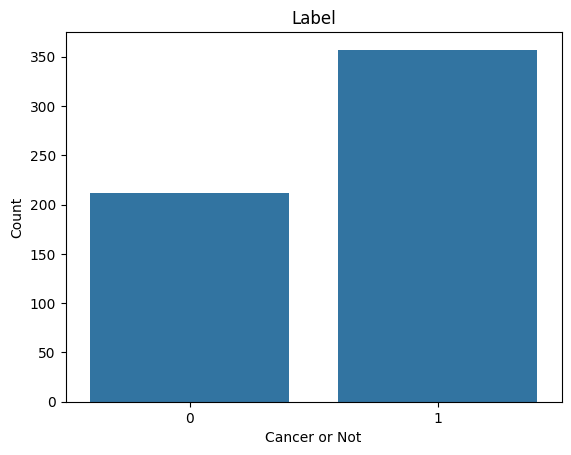

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 레이블 갯수 확인 (그래프)
sns.countplot(data = df, x="label")
plt.xlabel("Cancer or Not")
plt.ylabel("Count")
plt.title("Label")

In [ ]:
y=df['label'];
print(y.value_counts());

label
1    357
0    212
Name: count, dtype: int64


In [ ]:
y

,label
0,0
1,0
2,0
3,0
4,0
...,...
564,0
565,0
566,0
567,0


In [ ]:
X=df.drop('label',axis=1) # axis=1 열을 삭제해라
X.head()

,Unnamed: 0,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
from sklearn.model_selection import train_test_split

# 25퍼센트 시험용으로 떼어놓겠다
# 학습용 75%, 테스트용 25%
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25,random_state=0)

In [ ]:
X_train

,Unnamed: 0,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
293,293,11.850,17.46,75.54,432.7,0.08372,0.05642,0.026880,0.022800,0.1875,...,13.060,25.75,84.35,517.8,0.13690,0.17580,0.13160,0.09140,0.3101,0.07007
332,332,11.220,19.86,71.94,387.3,0.10540,0.06779,0.005006,0.007583,0.1940,...,11.980,25.78,76.91,436.1,0.14240,0.09669,0.01335,0.02022,0.3292,0.06522
565,565,20.130,28.25,131.20,1261.0,0.09780,0.10340,0.144000,0.097910,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.32150,0.16280,0.2572,0.06637
278,278,13.590,17.84,86.24,572.3,0.07948,0.04052,0.019970,0.012380,0.1573,...,15.500,26.10,98.91,739.1,0.10500,0.07622,0.10600,0.05185,0.2335,0.06263
489,489,16.690,20.20,107.10,857.6,0.07497,0.07112,0.036490,0.023070,0.1846,...,19.180,26.56,127.30,1084.0,0.10090,0.29200,0.24770,0.08737,0.4677,0.07623
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
277,277,18.810,19.98,120.90,1102.0,0.08923,0.05884,0.080200,0.058430,0.1550,...,19.960,24.30,129.00,1236.0,0.12430,0.11600,0.22100,0.12940,0.2567,0.05737
9,9,12.460,24.04,83.97,475.9,0.11860,0.23960,0.227300,0.085430,0.2030,...,15.090,40.68,97.65,711.4,0.18530,1.05800,1.10500,0.22100,0.4366,0.20750
359,359,9.436,18.32,59.82,278.6,0.10090,0.05956,0.027100,0.014060,0.1506,...,12.020,25.02,75.79,439.6,0.13330,0.10490,0.11440,0.05052,0.2454,0.08136
192,192,9.720,18.22,60.73,288.1,0.06950,0.02344,0.000000,0.000000,0.1653,...,9.968,20.83,62.25,303.8,0.07117,0.02729,0.00000,0.00000,0.1909,0.06559


In [ ]:
# Build a logistic regression classifier and predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

clf_lr = LogisticRegression(random_state=0) # 머신러닝 모델 빌드
clf_lr.fit(X_train, y_train) # 훈련

pred_lr = clf_lr.predict(X_test) # 정답이 없는 X_test만 할당

print ("\n--- Logistic Regression Classifier ---") # 예측한 값 실제 값 비교
print (accuracy_score(y_test, pred_lr)) # 정확도
print (confusion_matrix(y_test, pred_lr)) # 모델이 맞춘 것 / 틀린 것을 표로 보여주는 것


--- Logistic Regression Classifier ---
0.972027972027972
[[52  1]
 [ 3 87]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree Classifier
clf_dt = DecisionTreeClassifier(random_state=0)
clf_dt.fit(X_train, y_train) # 75%의 학습 데이터를 이용한 학습

pred_dt = clf_dt.predict(X_test) # 나머지 25%로 예측 진행

print("\n--- Decision Tree Classifier ---")
print(accuracy_score(y_test, pred_dt)) # 정확도 계산
print(confusion_matrix(y_test, pred_dt)) # 맞힌/틀린 개수 상세 표



--- Decision Tree Classifier ---
0.8951048951048951
[[49  4]
 [11 79]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest Classifier
clf_rf = RandomForestClassifier(random_state=0)
clf_rf.fit(X_train, y_train)

pred_rf = clf_rf.predict(X_test)

print("\n--- Random Forest Classifier ---")
print(accuracy_score(y_test, pred_rf))
print(confusion_matrix(y_test, pred_rf))


--- Random Forest Classifier ---
0.9790209790209791
[[52  1]
 [ 2 88]]


In [ ]:
print("LR Accuracy :", accuracy_score(y_test, pred_lr))
print("DT Accuracy :", accuracy_score(y_test, pred_dt))
print("RF Accuracy :", accuracy_score(y_test, pred_rf))

LR Accuracy : 0.972027972027972
DT Accuracy : 0.8951048951048951
RF Accuracy : 0.9790209790209791
